# Análise Exploratória de Dados — Produção de Óleo
**Projeto Aplicado IV — Etapa 2**  
Universidade Presbiteriana Mackenzie — Tecnologia em Ciência de Dados

**Alunos:** Felipe Fagion Longarini, Gleider Mackedanz de Campos, Lucas Oliveira  
**Professor:** Leandro Carlos Fernandes

---

## Objetivo
Realizar a análise exploratória da série temporal de produção de óleo dos campos **Tupi**, **Marlim**, **Sapinhoá** e **Canto do Amaro**, identificando componentes (tendência, sazonalidade, ciclos e ruído), verificando estacionariedade e levantando as técnicas de modelagem que serão utilizadas na Etapa 3.

## 1. Configuração e Importações

In [23]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Configurações de visualização
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='tab10')

CAMPOS_ALVO = ['TUPI', 'MARLIM', 'SAPINHOÁ', 'CANTO DO AMARO']
CORES = {'TUPI': '#1f77b4', 'MARLIM': '#ff7f0e', 'SAPINHOÁ': '#2ca02c', 'CANTO DO AMARO': '#d62728'}

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Carregamento e Inspeção Inicial dos Dados

In [25]:
df_raw = pd.read_csv('dados_campos_selecionados.csv', low_memory=False)

print(f'Dimensões: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')
print(f'\nColunas: {df_raw.columns.tolist()}')
df_raw.head(3)

Dimensões: 247,832 linhas × 19 colunas

Colunas: ['Estado', 'Bacia', 'NP_ANP', 'NP_Operador', 'Campo', 'Operador', 'Número do Contrato', 'Período', 'Óleo (bbl/dia)', 'Condensado (bbl/dia)', 'Petróleo (bbl/dia)', 'GN_Associado', 'GN_Não associado', 'GN_Gás Total', 'Volume Gás', 'Água (bbl/dia)', 'Instalação Destino', 'Tipo Instalação', 'Tempo de Produção (hs por mês)']


,Estado,Bacia,NP_ANP,NP_Operador,Campo,Operador,Número do Contrato,Período,Óleo (bbl/dia),Condensado (bbl/dia),Petróleo (bbl/dia),GN_Associado,GN_Não associado,GN_Gás Total,Volume Gás,Água (bbl/dia),Instalação Destino,Tipo Instalação,Tempo de Produção (hs por mês)
0,Rio de Janeiro,Campos,8-MRL-122HP-RJS,8MRL122HPRJS,MARLIM,Petrobras,480000037239710,2005/01,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0000,NaN,NaN,31.0
1,Rio de Janeiro,Campos,8-MRL-120D-RJS,8MRL 0120D RJS,MARLIM,Petrobras,480000037239710,2005/01,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0000,NaN,NaN,31.0
2,Rio de Janeiro,Campos,7-MRL-100H-RJS,7MRL 0100H RJS,MARLIM,Petrobras,480000037239710,2005/01,10116.4716,0.0,10116.4716,0.0,0.0,0.0,0.0,2072.0237,NaN,NaN,31.0


In [27]:
# Converter Período para datetime
df_raw['Período'] = pd.to_datetime(df_raw['Período'], format='%Y/%m')

# Converter variáveis numéricas
colunas_num = [
    'Óleo (bbl/dia)', 'Condensado (bbl/dia)', 'Petróleo (bbl/dia)',
    'GN_Associado', 'GN_Não associado', 'GN_Gás Total', 'Volume Gás',
    'Água (bbl/dia)', 'Tempo de Produção (hs por mês)'
]
for col in colunas_num:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print('Tipos de dados após conversão:')
print(df_raw.dtypes)

Tipos de dados após conversão:
Estado                                    object
Bacia                                     object
NP_ANP                                    object
NP_Operador                               object
Campo                                     object
Operador                                  object
Número do Contrato                         int64
Período                           datetime64[ns]
Óleo (bbl/dia)                           float64
Condensado (bbl/dia)                     float64
Petróleo (bbl/dia)                       float64
GN_Associado                             float64
GN_Não associado                         float64
GN_Gás Total                             float64
Volume Gás                               float64
Água (bbl/dia)                           float64
Instalação Destino                        object
Tipo Instalação                           object
Tempo de Produção (hs por mês)           float64
dtype: object


In [4]:
# Análise de valores nulos
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
resumo_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': nulos_pct})
print('Valores nulos por coluna:')
print(resumo_nulos[resumo_nulos['Nulos'] > 0])

Valores nulos por coluna:
                      Nulos  % Nulos
Instalação Destino  1312079     62.2
Tipo Instalação     1312079     62.2


## 3. Filtro e Preparação dos 4 Campos de Interesse

In [5]:
df_campos = df_raw[df_raw['Campo'].isin(CAMPOS_ALVO)].copy()

# Agregar produção mensal por campo (somar todos os poços do mesmo campo e período)
df_mensal = (
    df_campos
    .groupby(['Campo', 'Período'], as_index=False)
    .agg({
        'Óleo (bbl/dia)': 'sum',
        'Água (bbl/dia)': 'sum',
        'GN_Gás Total': 'sum',
        'Tempo de Produção (hs por mês)': 'sum',
        'Petróleo (bbl/dia)': 'sum'
    })
    .sort_values(['Campo', 'Período'])
)

print(f'Registros após filtro: {len(df_mensal)}')
df_mensal.head()

Registros após filtro: 552


,Campo,Período,Óleo (bbl/dia),Água (bbl/dia),GN_Gás Total,Tempo de Produção (hs por mês),Petróleo (bbl/dia)
0,CANTO DO AMARO,2005-01-01,31344.0920,109777.2845,0.0444,35247.0,31344.0920
1,CANTO DO AMARO,2005-02-01,30937.4341,111933.7163,0.0474,31892.0,30937.4341
2,CANTO DO AMARO,2005-03-01,29945.4478,108403.3326,0.0343,35712.0,29945.4478
3,CANTO DO AMARO,2005-04-01,29870.3962,107128.1221,0.0275,34380.0,29870.3962
4,CANTO DO AMARO,2005-05-01,29997.2226,112819.4724,0.0236,35464.0,29997.2226


In [6]:
# Cobertura temporal por campo
cobertura = df_mensal.groupby('Campo')['Período'].agg(['min', 'max', 'count'])
cobertura.columns = ['Início', 'Fim', 'N° Meses']
print('Cobertura temporal por campo:')
print(cobertura)

Cobertura temporal por campo:
                   Início        Fim  N° Meses
Campo                                         
CANTO DO AMARO 2005-01-01 2022-03-01       207
MARLIM         2005-01-01 2022-03-01       207
SAPINHOÁ       2010-12-01 2022-03-01       117
TUPI           2020-07-01 2022-03-01        21


## 4. Estatísticas Descritivas

In [7]:
stats = (
    df_mensal
    .groupby('Campo')['Óleo (bbl/dia)']
    .agg(['mean', 'std', 'min', 'median', 'max'])
    .round(1)
)
stats.columns = ['Média', 'Desvio Padrão', 'Mínimo', 'Mediana', 'Máximo']
print('Estatísticas descritivas — Produção de Óleo (bbl/dia):')
print(stats)

Estatísticas descritivas — Produção de Óleo (bbl/dia):
                    Média  Desvio Padrão     Mínimo    Mediana     Máximo
Campo                                                                    
CANTO DO AMARO    17490.6         6676.1     7020.1    18649.4    32346.3
MARLIM           214207.0       120205.1    22618.7   188614.2   480853.0
SAPINHOÁ         341370.2       179718.6     3145.7   406745.4   533268.2
TUPI            1820523.3        77479.1  1697300.8  1802045.1  2007431.9


In [28]:
# Tabela de coeficiente de variação (dispersão relativa)
stats['CV (%)'] = (stats['Desvio Padrão'] / stats['Média'] * 100).round(1)
print('Coeficiente de Variação por Campo:')
print(stats[['Média', 'Desvio Padrão', 'CV (%)']])

Coeficiente de Variação por Campo:
                    Média  Desvio Padrão  CV (%)
Campo                                           
CANTO DO AMARO    17490.6         6676.1    38.2
MARLIM           214207.0       120205.1    56.1
SAPINHOÁ         341370.2       179718.6    52.6
TUPI            1820523.3        77479.1     4.3


## 5. Visualizações — Componentes da Série Temporal

### 5.1 Gráficos de Linha — Produção ao Longo do Tempo

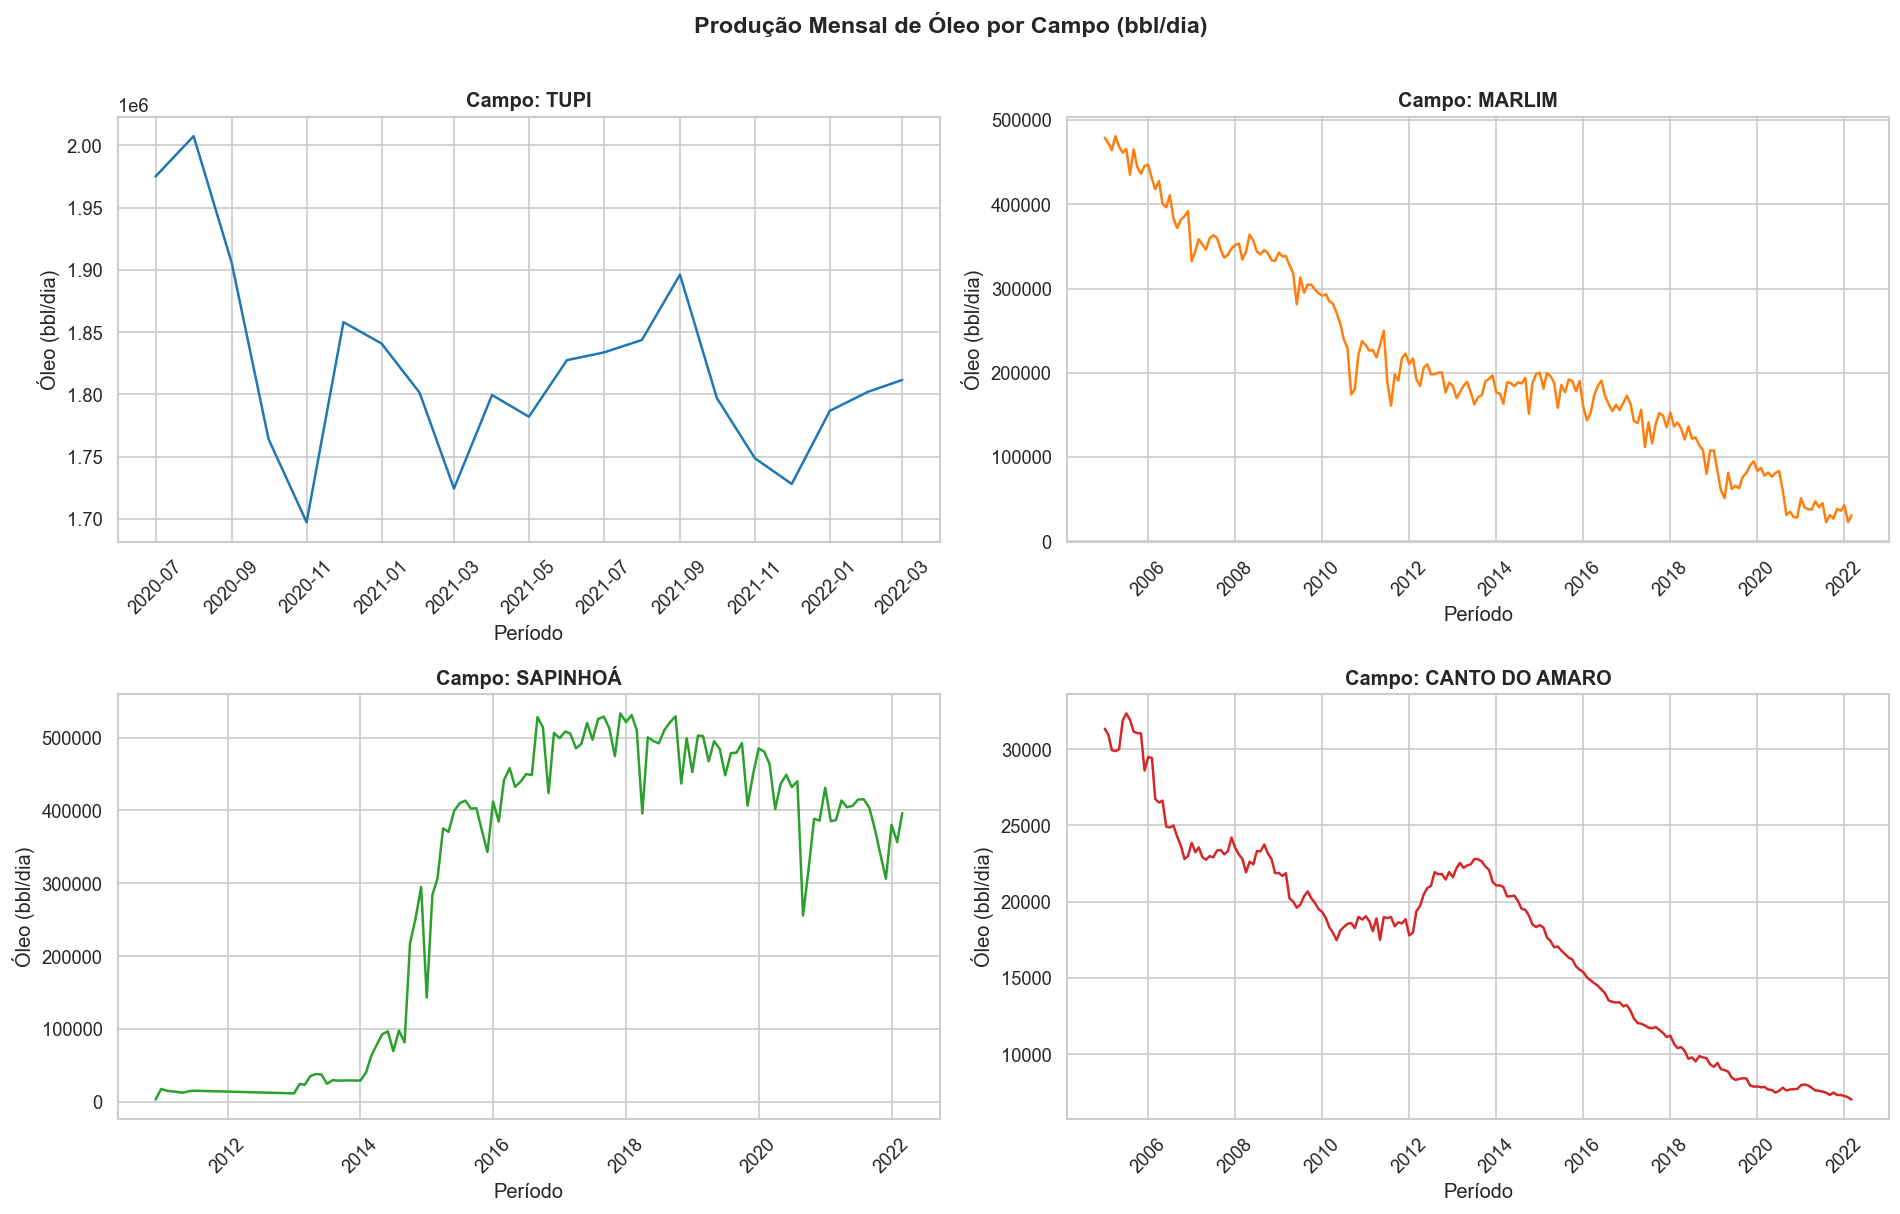

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

for i, campo in enumerate(CAMPOS_ALVO):
    dados = df_mensal[df_mensal['Campo'] == campo]
    axes[i].plot(dados['Período'], dados['Óleo (bbl/dia)'],
                 color=CORES[campo], linewidth=1.5)
    axes[i].set_title(f'Campo: {campo}', fontweight='bold')
    axes[i].set_ylabel('Óleo (bbl/dia)')
    axes[i].set_xlabel('Período')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Produção Mensal de Óleo por Campo (bbl/dia)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

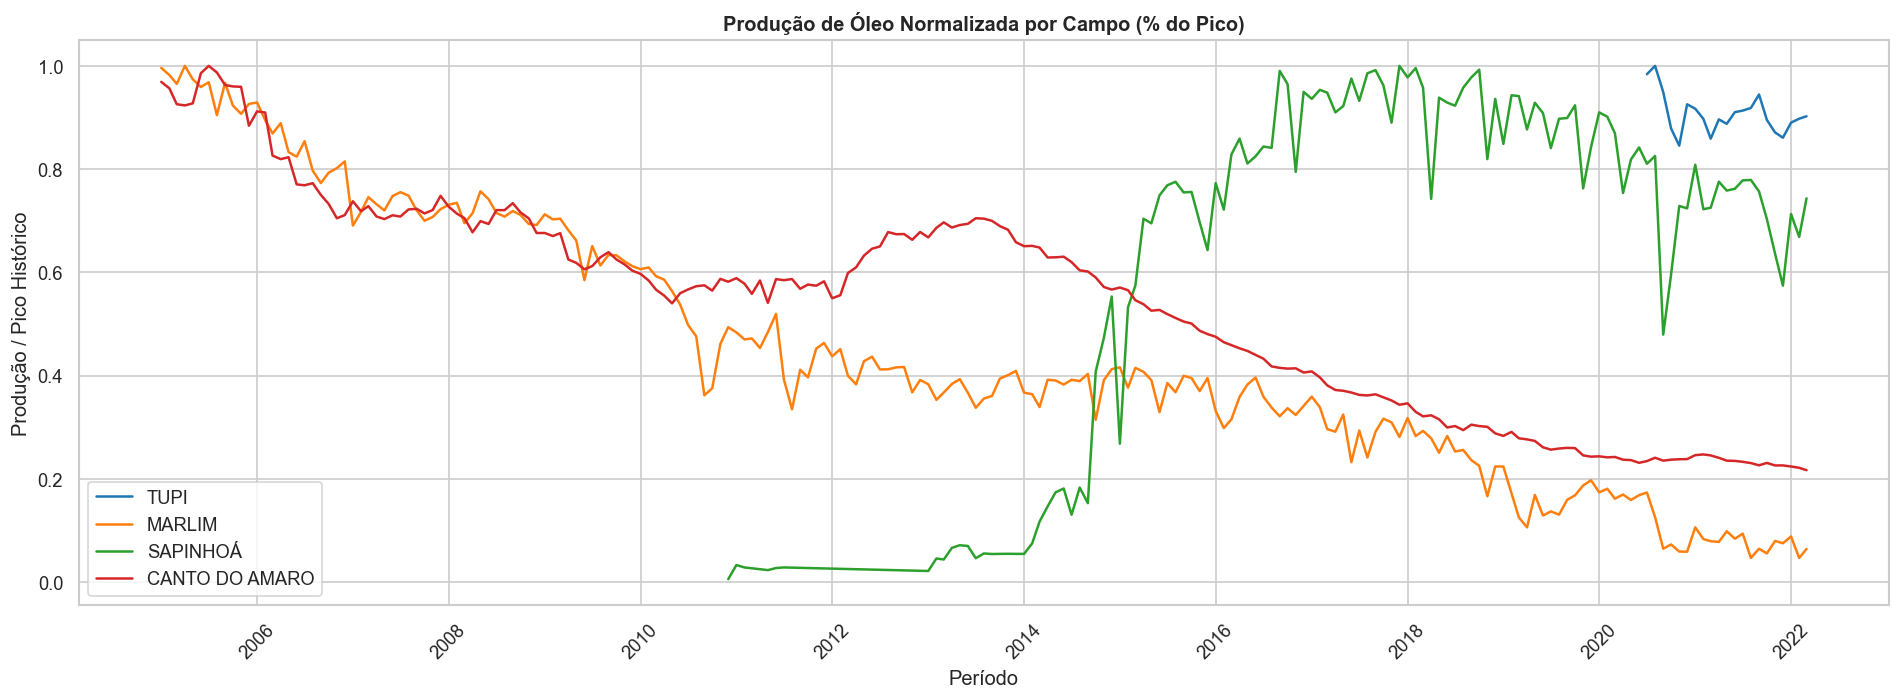

In [10]:
# Gráfico sobreposto — comparação relativa (normalizado)
fig, ax = plt.subplots(figsize=(16, 6))

for campo in CAMPOS_ALVO:
    dados = df_mensal[df_mensal['Campo'] == campo]
    serie = dados.set_index('Período')['Óleo (bbl/dia)']
    max_val = serie.max()
    if max_val > 0:
        ax.plot(serie.index, serie / max_val, label=campo, color=CORES[campo], linewidth=1.5)

ax.set_title('Produção de Óleo Normalizada por Campo (% do Pico)', fontweight='bold')
ax.set_ylabel('Produção / Pico Histórico')
ax.set_xlabel('Período')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.2 Box Plots — Padrão Sazonal e Tendência Anual

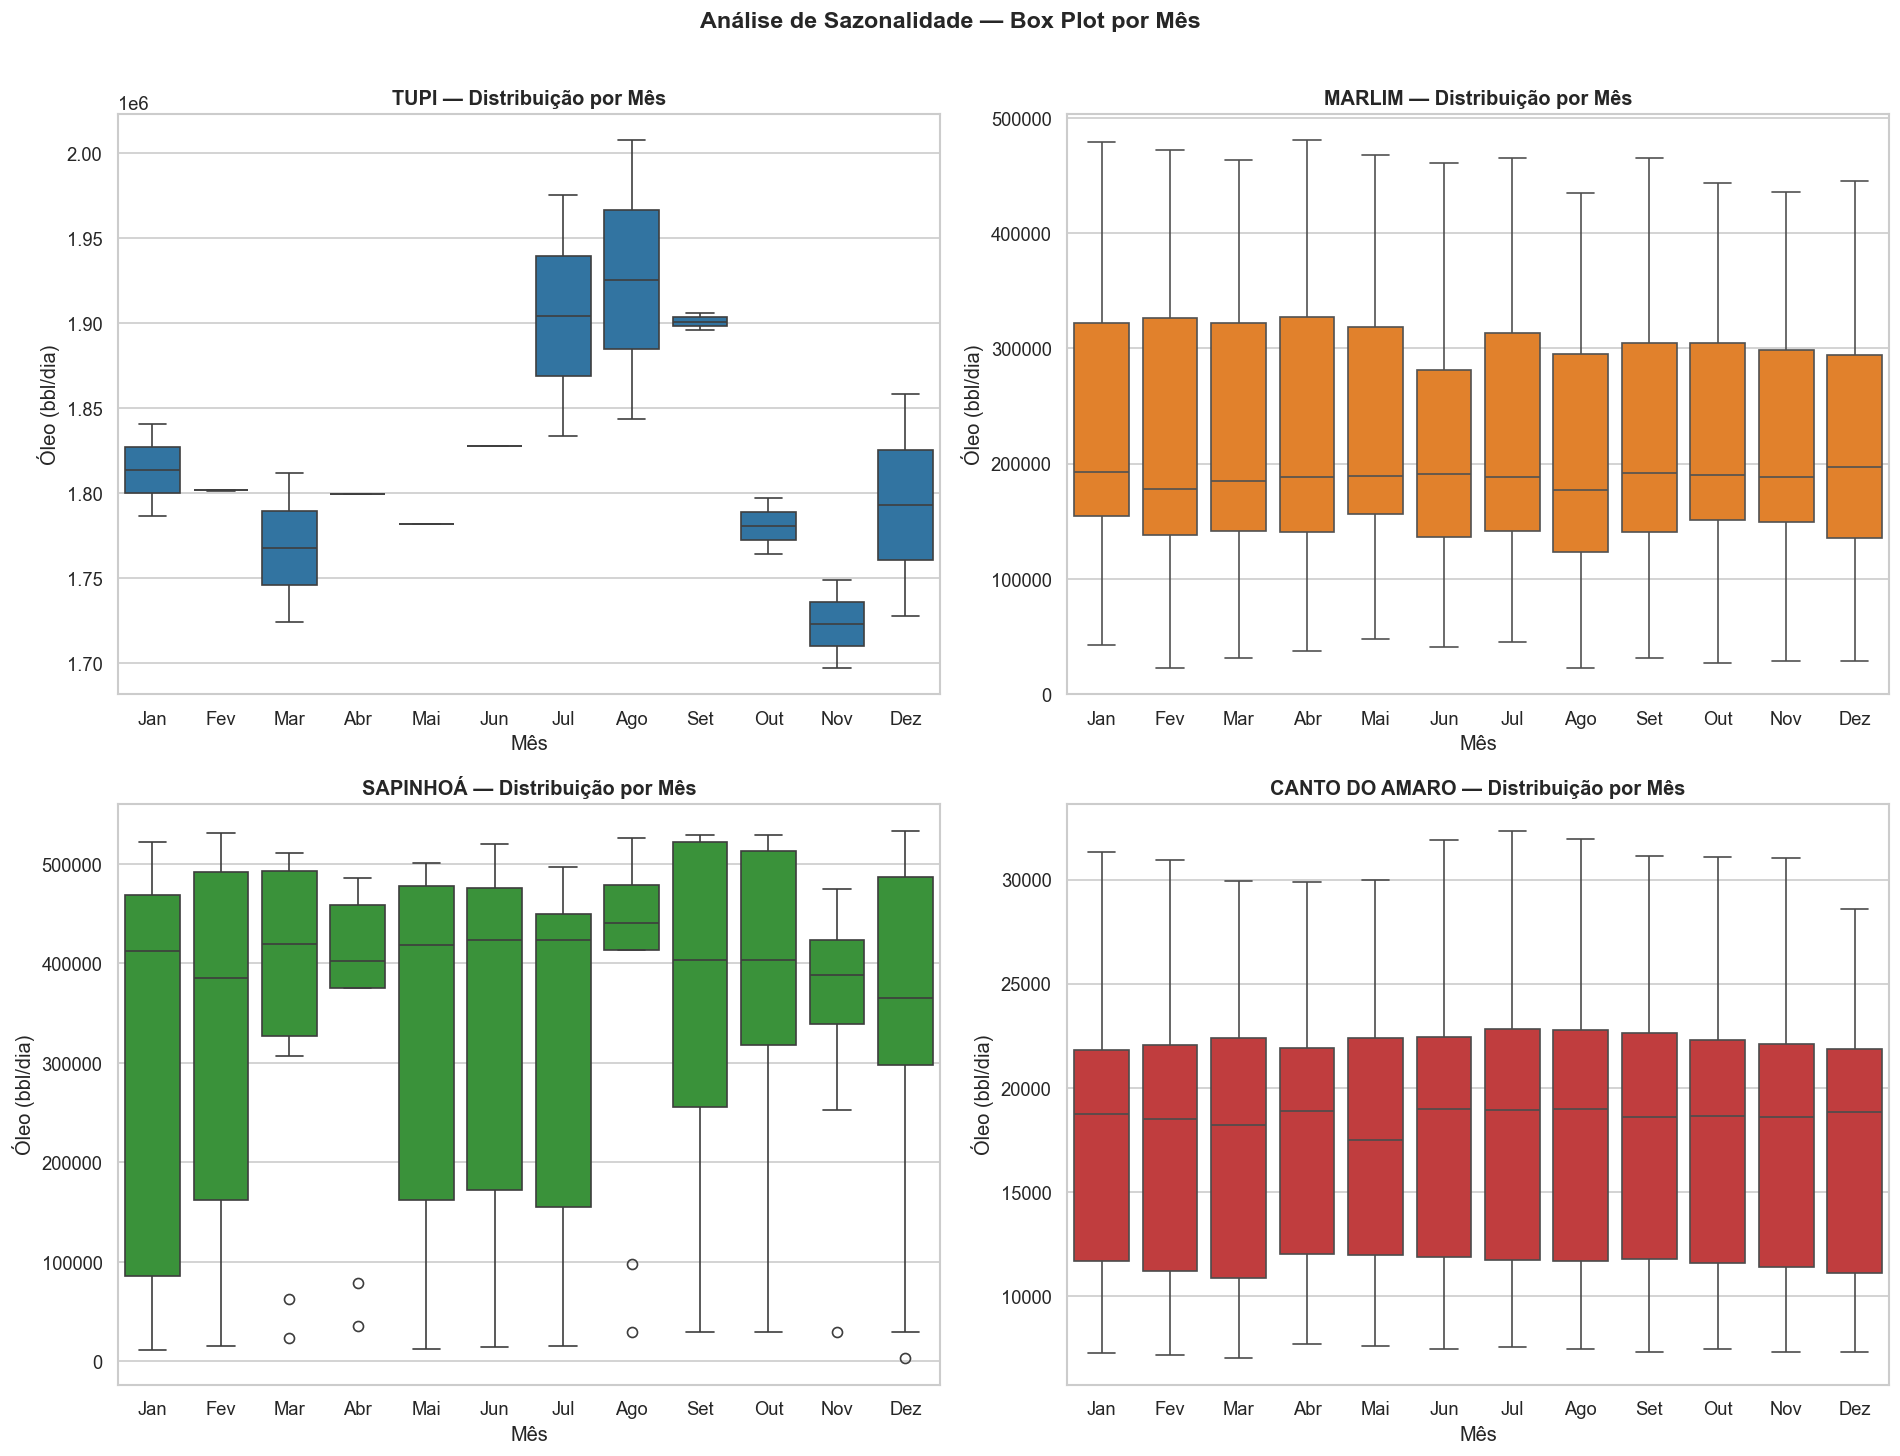

In [11]:
df_mensal['Mês'] = df_mensal['Período'].dt.month
df_mensal['Ano'] = df_mensal['Período'].dt.year

meses_pt = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
            7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
df_mensal['Mês_Nome'] = df_mensal['Mês'].map(meses_pt)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, campo in enumerate(CAMPOS_ALVO):
    dados = df_mensal[df_mensal['Campo'] == campo]
    ordem_meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
    sns.boxplot(
        data=dados, x='Mês_Nome', y='Óleo (bbl/dia)',
        order=ordem_meses, ax=axes[i], color=CORES[campo]
    )
    axes[i].set_title(f'{campo} — Distribuição por Mês', fontweight='bold')
    axes[i].set_ylabel('Óleo (bbl/dia)')
    axes[i].set_xlabel('Mês')

plt.suptitle('Análise de Sazonalidade — Box Plot por Mês', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

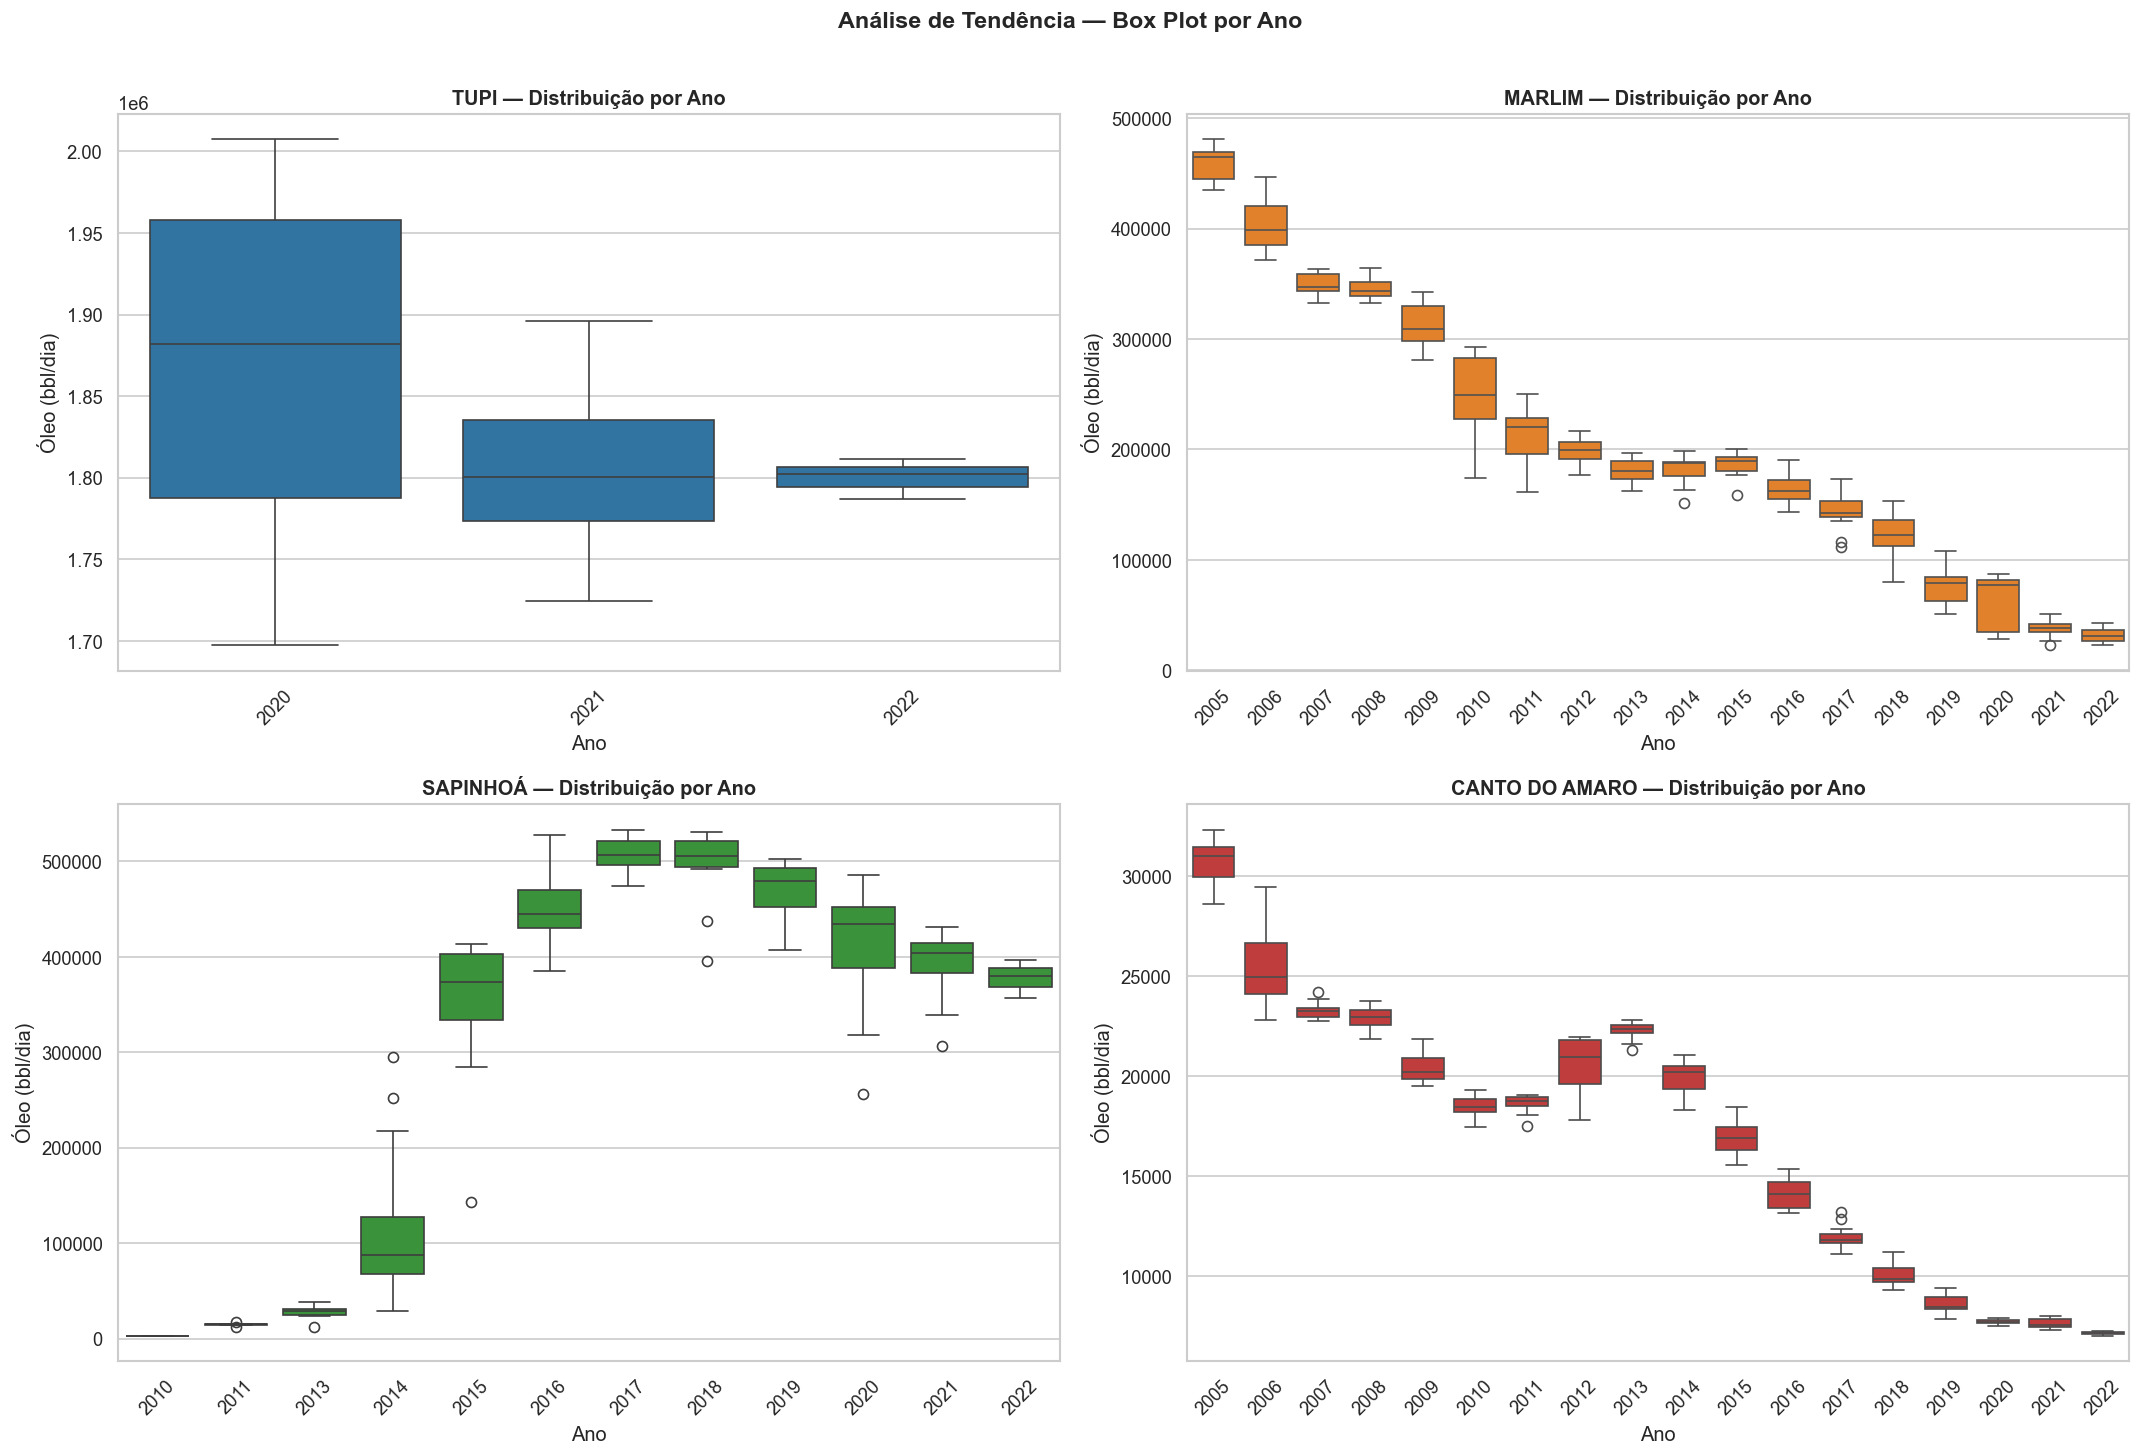

In [12]:
# Box plot por ano — tendência inter-anual
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, campo in enumerate(CAMPOS_ALVO):
    dados = df_mensal[df_mensal['Campo'] == campo]
    sns.boxplot(
        data=dados, x='Ano', y='Óleo (bbl/dia)',
        ax=axes[i], color=CORES[campo]
    )
    axes[i].set_title(f'{campo} — Distribuição por Ano', fontweight='bold')
    axes[i].set_ylabel('Óleo (bbl/dia)')
    axes[i].set_xlabel('Ano')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Análise de Tendência — Box Plot por Ano', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Decomposição da Série Temporal

Separação dos componentes: **Tendência**, **Sazonalidade** e **Resíduo** (BOX; JENKINS, 2015).

[TUPI] Série muito curta para decomposição (21 obs).


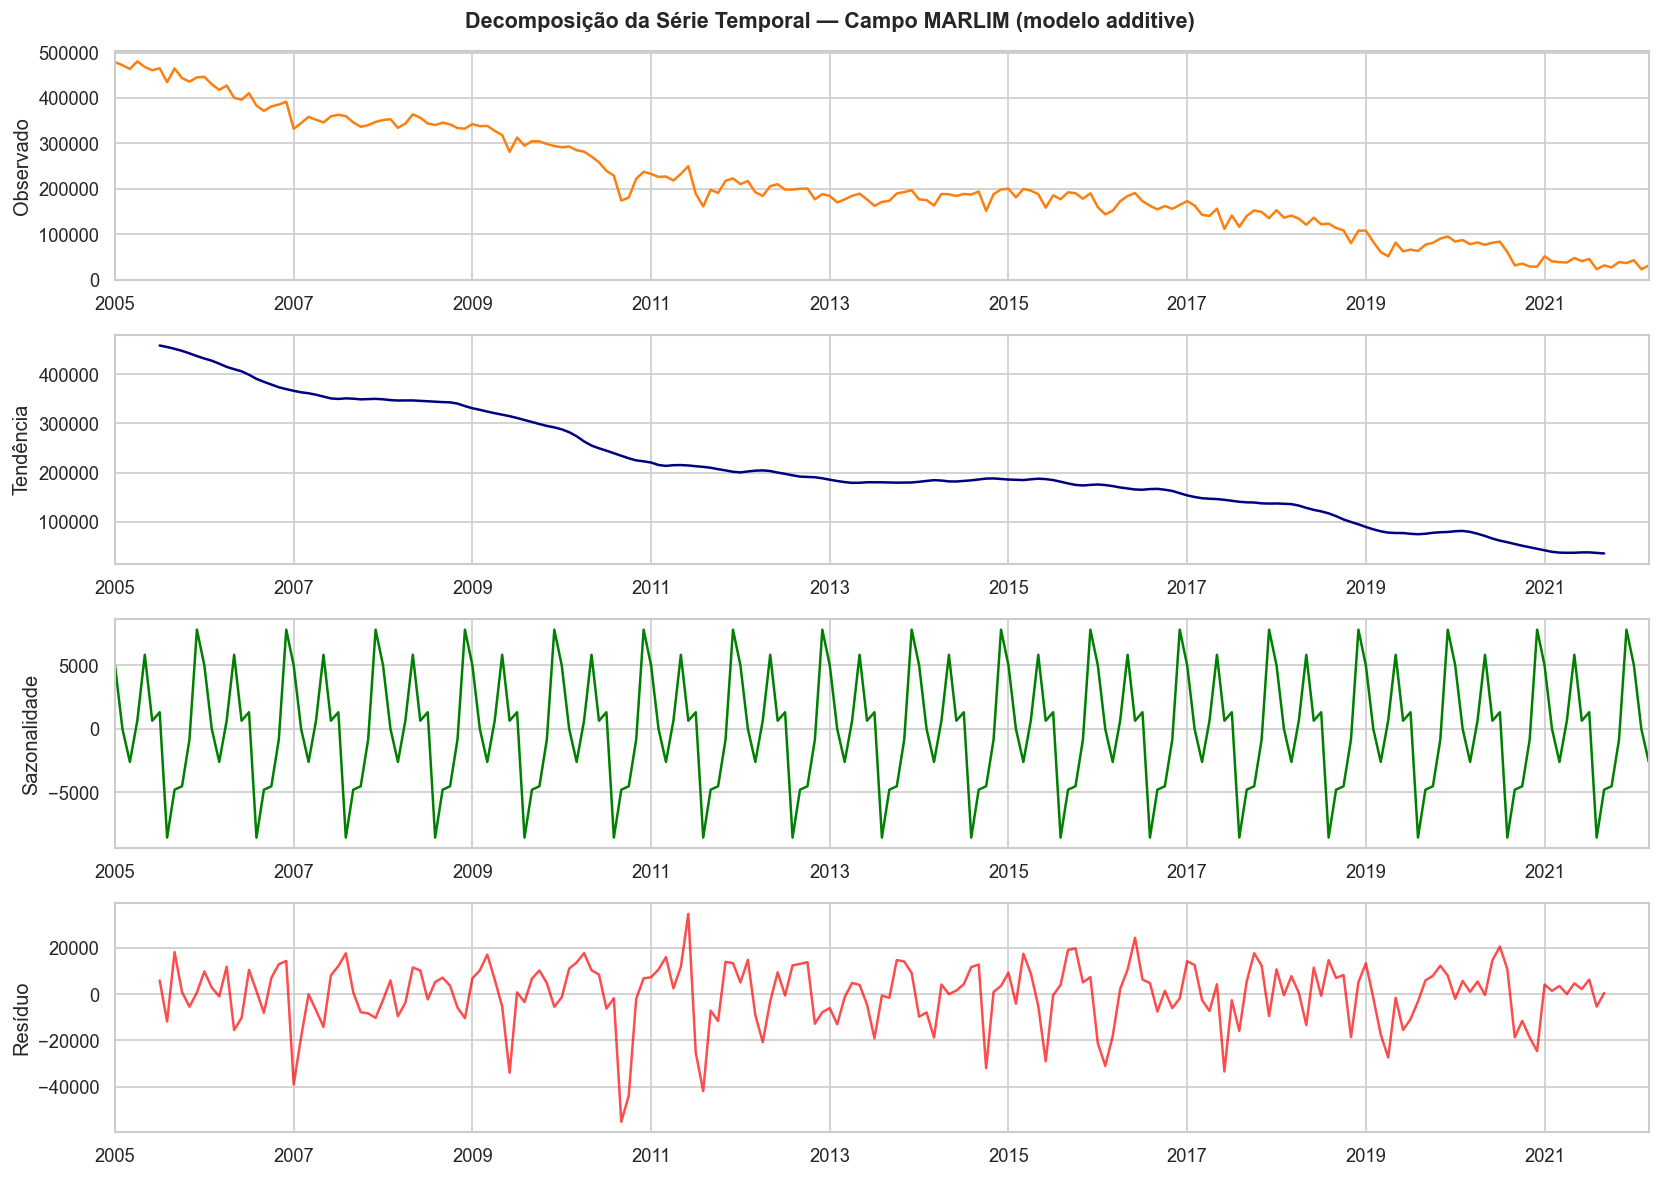

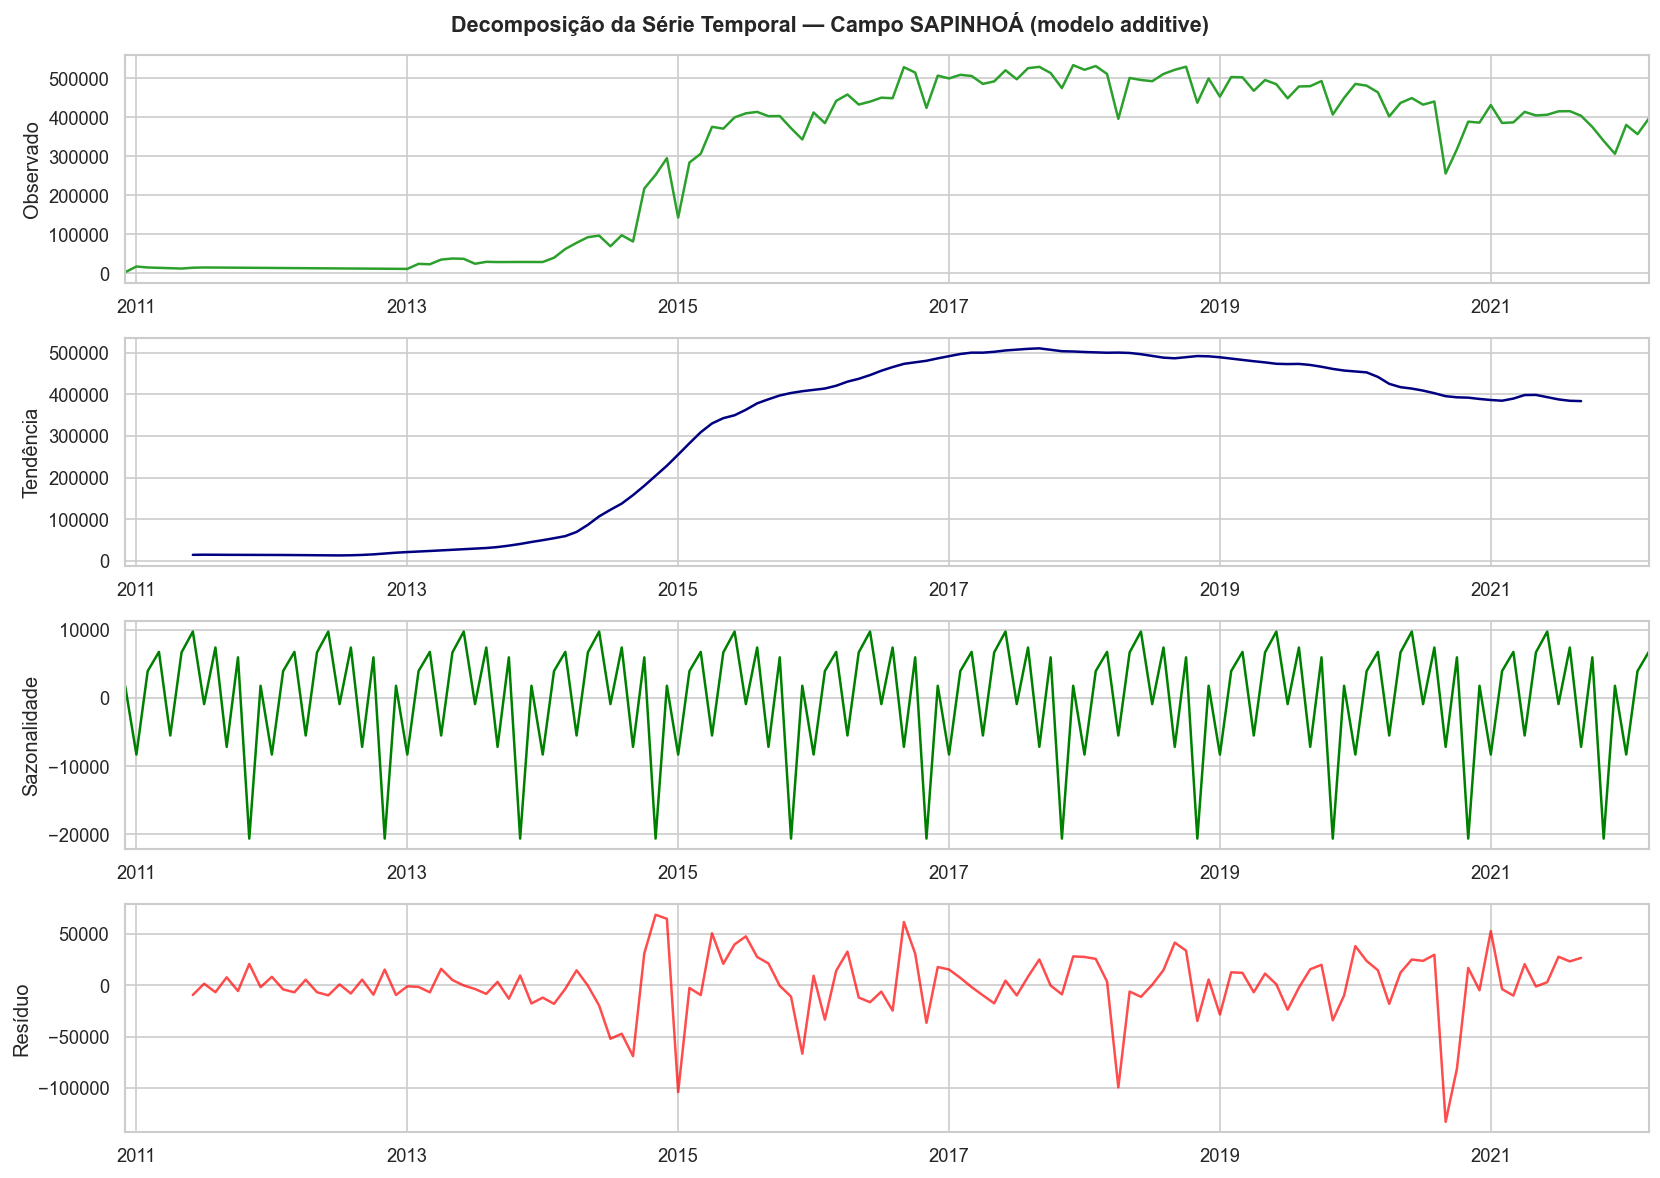

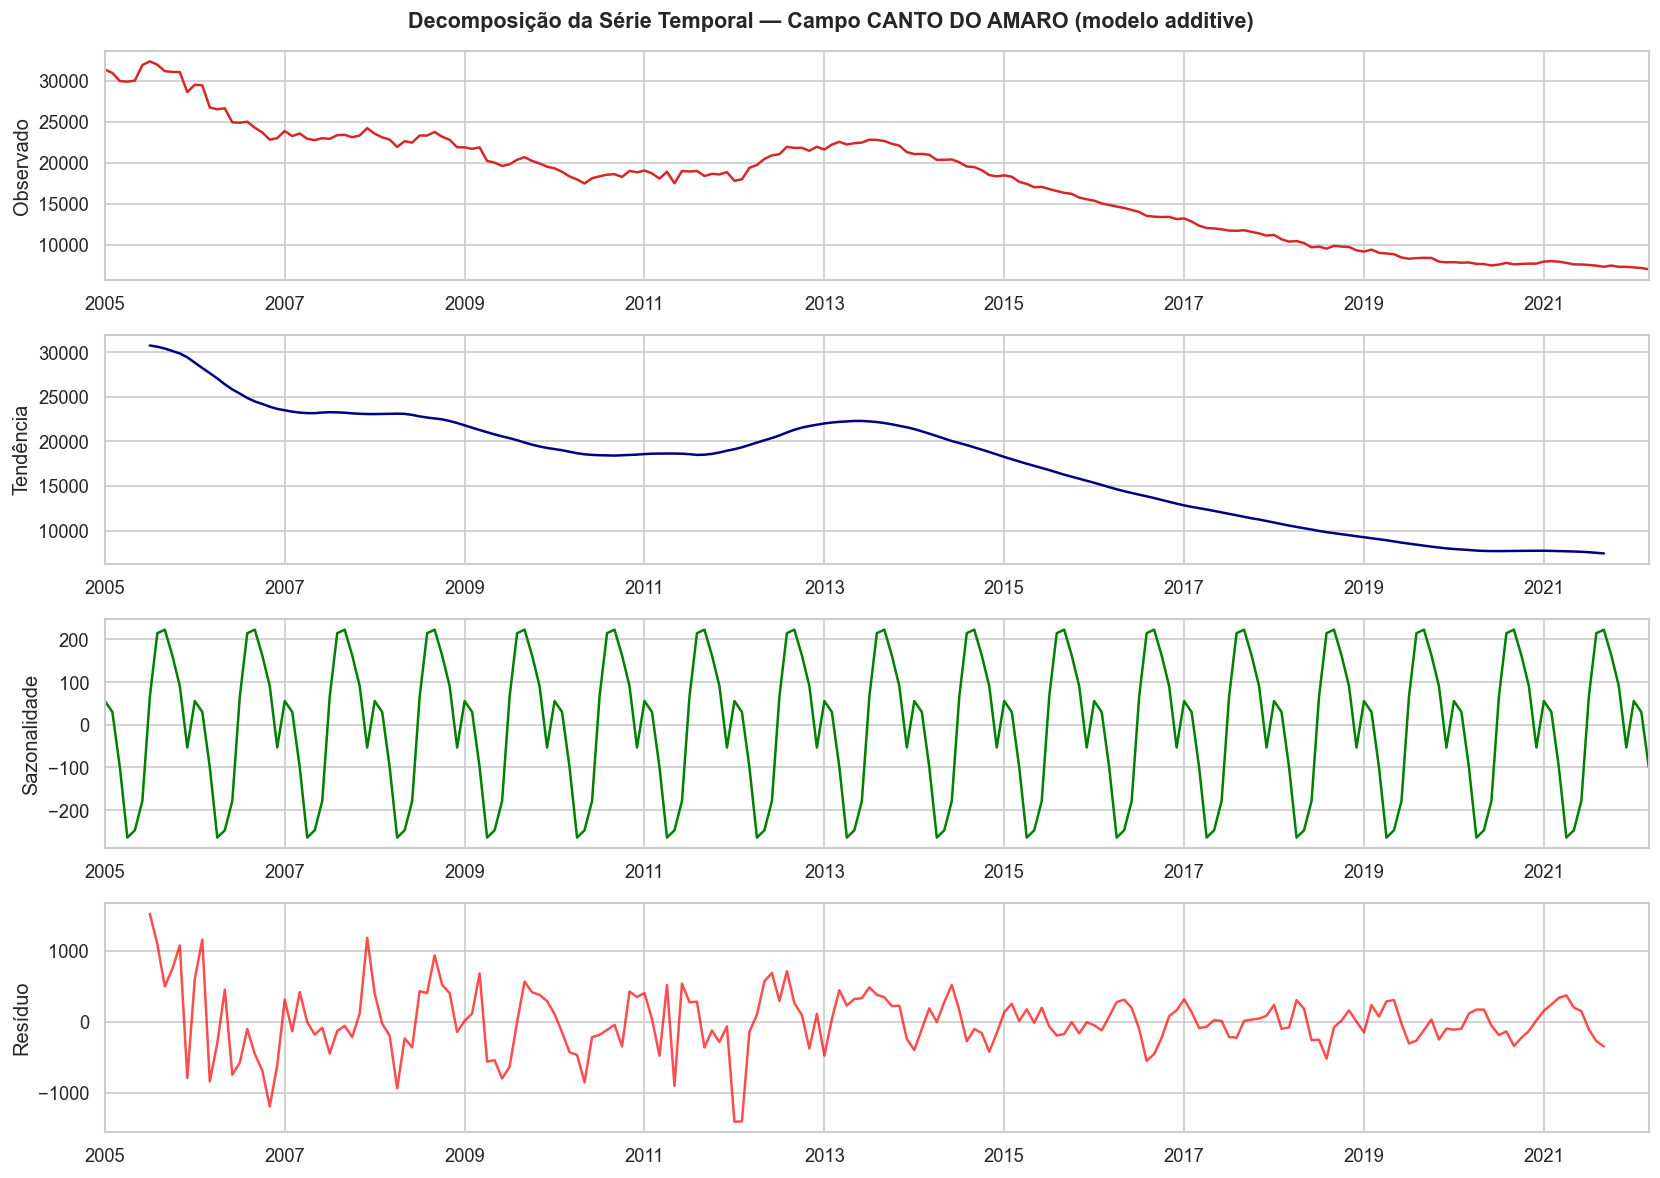

In [13]:
def decompor_campo(campo, modelo='additive'):
    dados = (
        df_mensal[df_mensal['Campo'] == campo]
        .set_index('Período')['Óleo (bbl/dia)']
        .sort_index()
    )
    # Remover zeros iniciais/finais e interpoler gaps pontuais
    dados = dados[dados > 0]
    dados = dados.asfreq('MS').interpolate(method='linear')

    if len(dados) < 24:
        print(f'[{campo}] Série muito curta para decomposição ({len(dados)} obs).')
        return

    decomposicao = seasonal_decompose(dados, model=modelo, period=12)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    decomposicao.observed.plot(ax=axes[0], color=CORES[campo])
    axes[0].set_ylabel('Observado')
    decomposicao.trend.plot(ax=axes[1], color='navy')
    axes[1].set_ylabel('Tendência')
    decomposicao.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_ylabel('Sazonalidade')
    decomposicao.resid.plot(ax=axes[3], color='red', alpha=0.7)
    axes[3].set_ylabel('Resíduo')

    for ax in axes:
        ax.set_xlabel('')

    plt.suptitle(f'Decomposição da Série Temporal — Campo {campo} (modelo {modelo})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

for campo in CAMPOS_ALVO:
    decompor_campo(campo, modelo='additive')

### 5.4 Heat Map de Correlação entre Variáveis

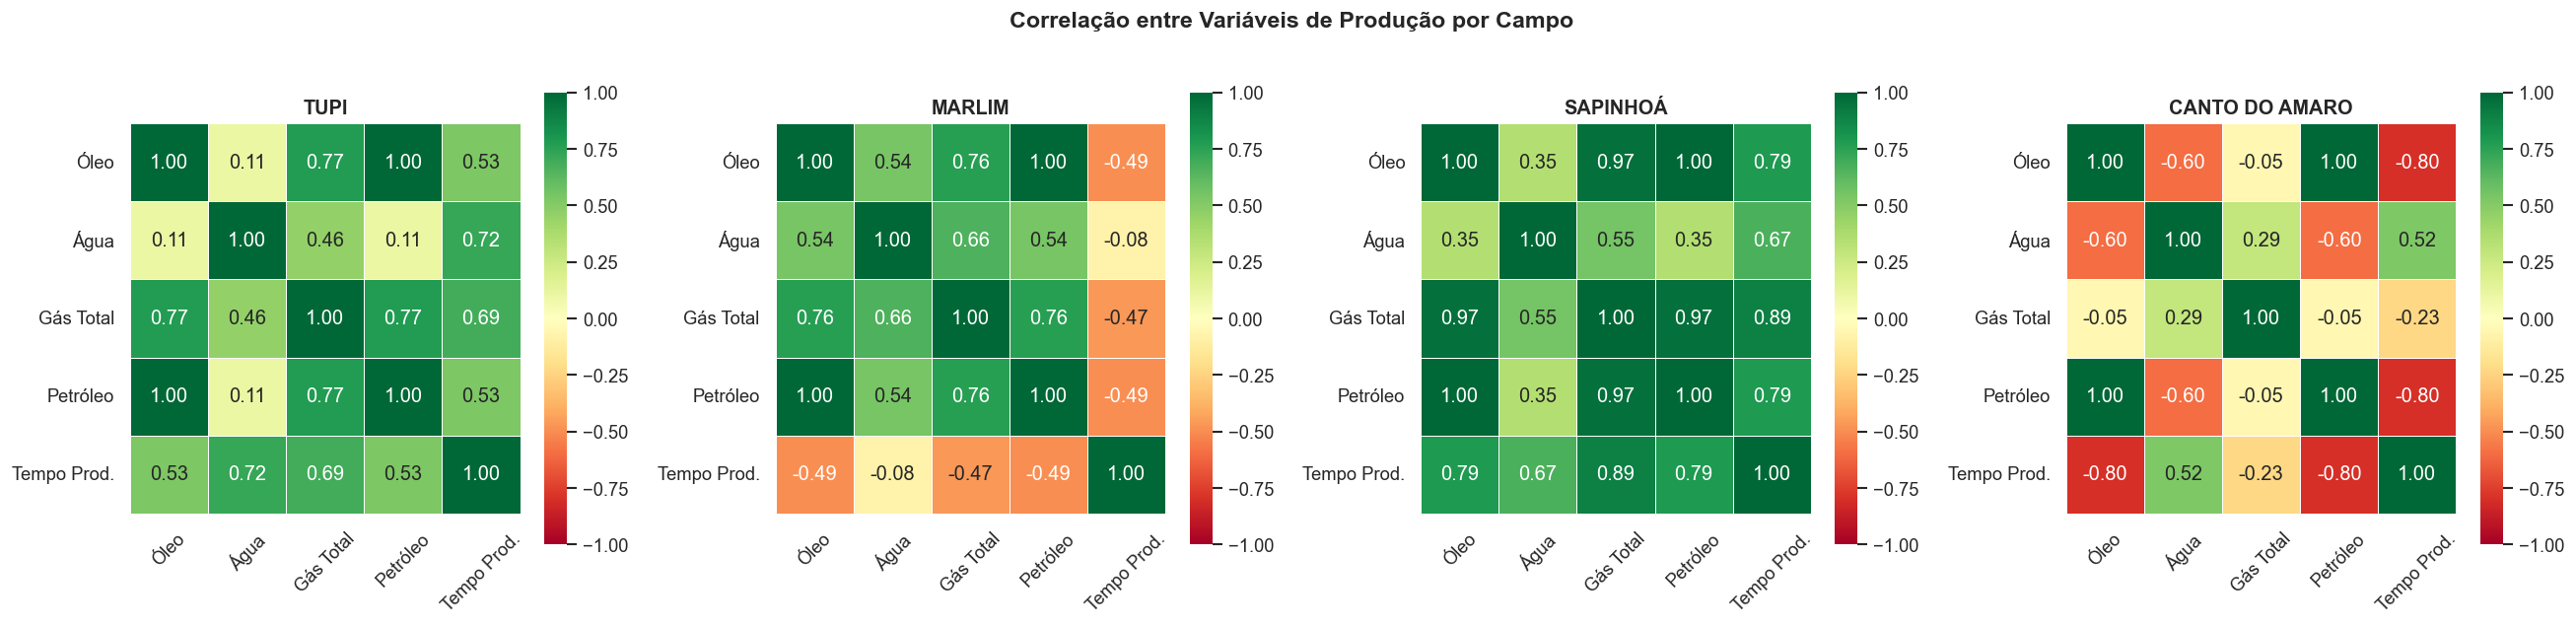

In [14]:
variaveis_corr = ['Óleo (bbl/dia)', 'Água (bbl/dia)', 'GN_Gás Total',
                  'Petróleo (bbl/dia)', 'Tempo de Produção (hs por mês)']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, campo in enumerate(CAMPOS_ALVO):
    dados = df_mensal[df_mensal['Campo'] == campo][variaveis_corr].dropna()
    corr = dados.corr()
    rotulos = ['Óleo', 'Água', 'Gás Total', 'Petróleo', 'Tempo Prod.']
    sns.heatmap(
        corr, ax=axes[i], annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=-1, vmax=1,
        xticklabels=rotulos, yticklabels=rotulos,
        square=True, linewidths=0.5
    )
    axes[i].set_title(campo, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Correlação entre Variáveis de Produção por Campo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Análise de Autocorrelação (ACF e PACF)

Os gráficos ACF e PACF auxiliam na escolha dos parâmetros *p* e *q* do modelo ARIMA (BOX; JENKINS, 2015).

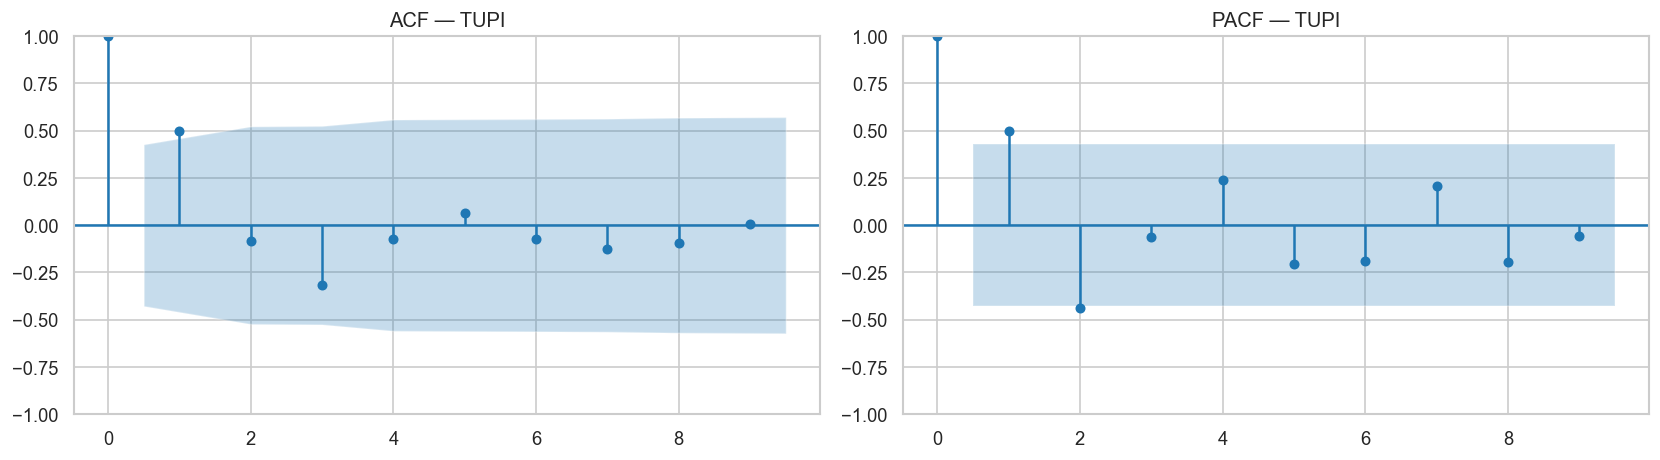

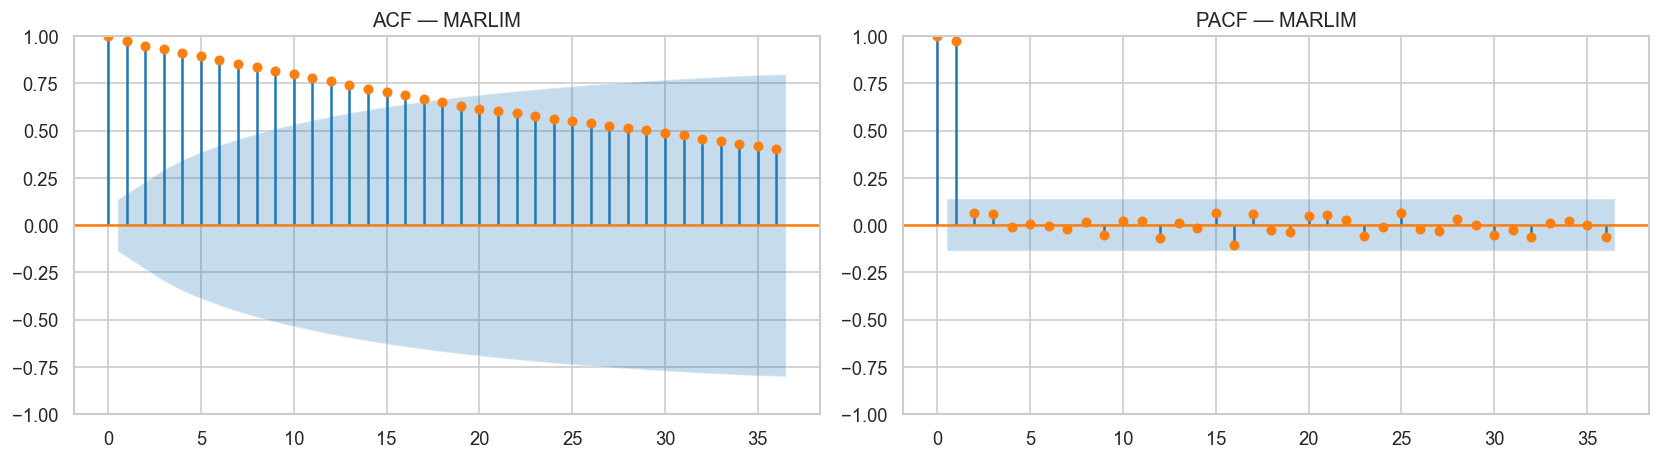

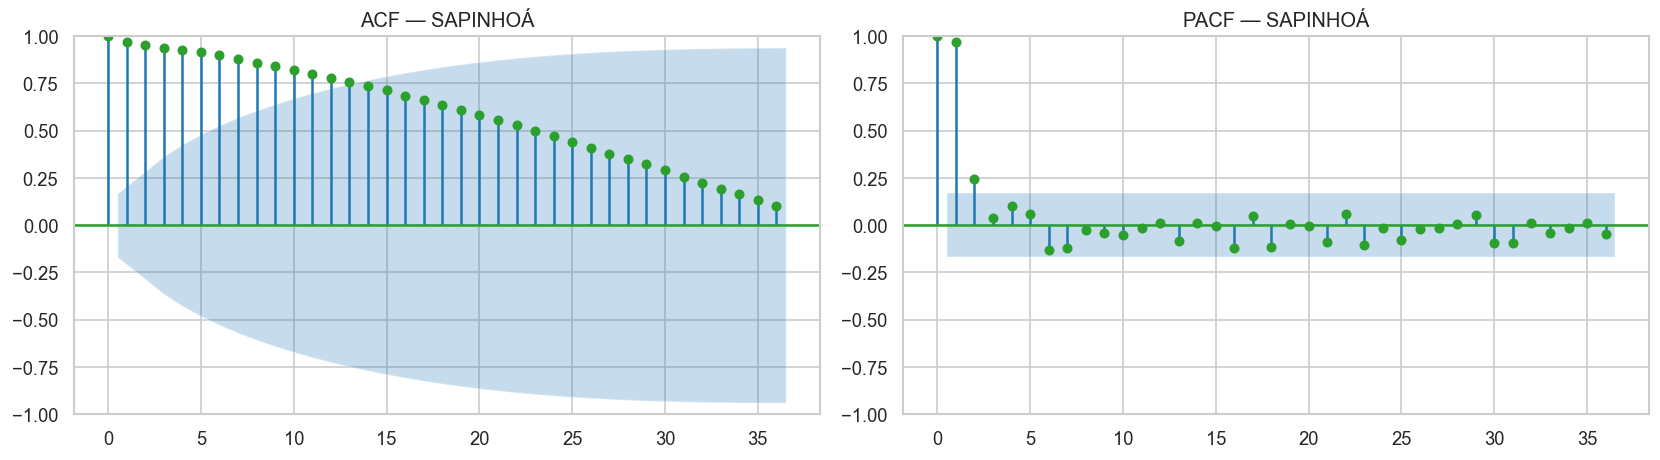

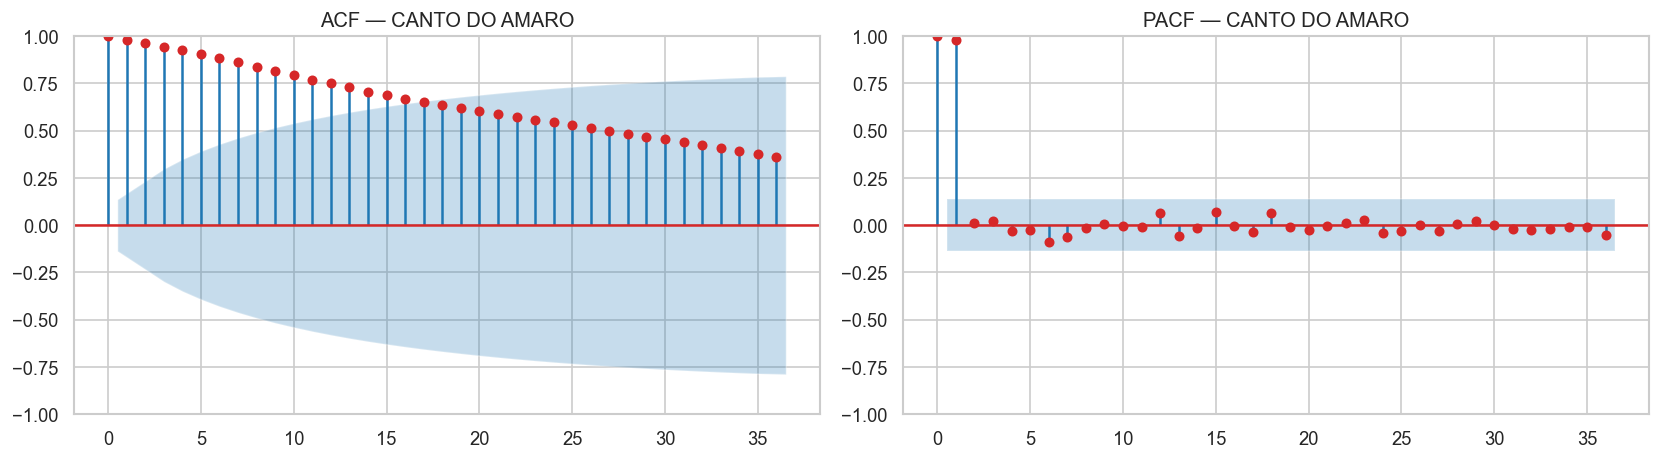

In [15]:
def plotar_acf_pacf(campo):
    dados = (
        df_mensal[df_mensal['Campo'] == campo]
        .set_index('Período')['Óleo (bbl/dia)']
        .sort_index()
    )
    dados = dados[dados > 0].asfreq('MS').interpolate(method='linear')

    if len(dados) < 20:
        print(f'[{campo}] Série muito curta para ACF/PACF.')
        return

    n_lags = min(36, len(dados) // 2 - 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(dados, lags=n_lags, ax=ax1, color=CORES[campo])
    ax1.set_title(f'ACF — {campo}')
    plot_pacf(dados, lags=n_lags, ax=ax2, color=CORES[campo], method='ywm')
    ax2.set_title(f'PACF — {campo}')
    plt.tight_layout()
    plt.show()

for campo in CAMPOS_ALVO:
    plotar_acf_pacf(campo)

## 6. Análise de Estacionariedade

Uma série é **estacionária** quando possui média e variância constantes ao longo do tempo. O teste ADF (Augmented Dickey-Fuller) testa a hipótese nula de que a série possui raiz unitária (não estacionária). Se o p-valor < 0,05, rejeita-se H₀ e a série é considerada estacionária (MORETTIN; TOLOI, 2006).

In [16]:
def teste_adf(serie, nome=''):
    resultado = adfuller(serie.dropna(), autolag='AIC')
    estacionaria = resultado[1] < 0.05
    return {
        'Campo': nome,
        'ADF Statistic': round(resultado[0], 4),
        'p-valor': round(resultado[1], 4),
        'Lags usados': resultado[2],
        'Estacionária?': 'Sim' if estacionaria else 'Não'
    }

resultados_adf = []

for campo in CAMPOS_ALVO:
    dados = (
        df_mensal[df_mensal['Campo'] == campo]
        .set_index('Período')['Óleo (bbl/dia)']
        .sort_index()
    )
    dados = dados[dados > 0].asfreq('MS').interpolate(method='linear')

    if len(dados) >= 15:
        resultados_adf.append(teste_adf(dados, campo))

df_adf = pd.DataFrame(resultados_adf)
print('Resultado do Teste ADF — Série Original:')
print(df_adf.to_string(index=False))

Resultado do Teste ADF — Série Original:
         Campo  ADF Statistic  p-valor  Lags usados Estacionária?
          TUPI        -2.8876   0.0468            0           Sim
        MARLIM        -1.8445   0.3586            5           Não
      SAPINHOÁ        -1.4402   0.5629            6           Não
CANTO DO AMARO        -1.1052   0.7130            2           Não


In [17]:
# Para séries não estacionárias: aplicar diferenciação de 1ª ordem e re-testar
resultados_adf_diff = []

for campo in CAMPOS_ALVO:
    dados = (
        df_mensal[df_mensal['Campo'] == campo]
        .set_index('Período')['Óleo (bbl/dia)']
        .sort_index()
    )
    dados = dados[dados > 0].asfreq('MS').interpolate(method='linear')

    if len(dados) >= 15:
        dados_diff = dados.diff().dropna()
        resultados_adf_diff.append(teste_adf(dados_diff, campo))

df_adf_diff = pd.DataFrame(resultados_adf_diff)
print('Resultado do Teste ADF — Série Diferenciada (1ª ordem):')
print(df_adf_diff.to_string(index=False))

Resultado do Teste ADF — Série Diferenciada (1ª ordem):
         Campo  ADF Statistic  p-valor  Lags usados Estacionária?
          TUPI        -4.0501   0.0012            0           Sim
        MARLIM       -11.4343   0.0000            2           Sim
      SAPINHOÁ        -4.2520   0.0005            5           Sim
CANTO DO AMARO       -10.2268   0.0000            1           Sim


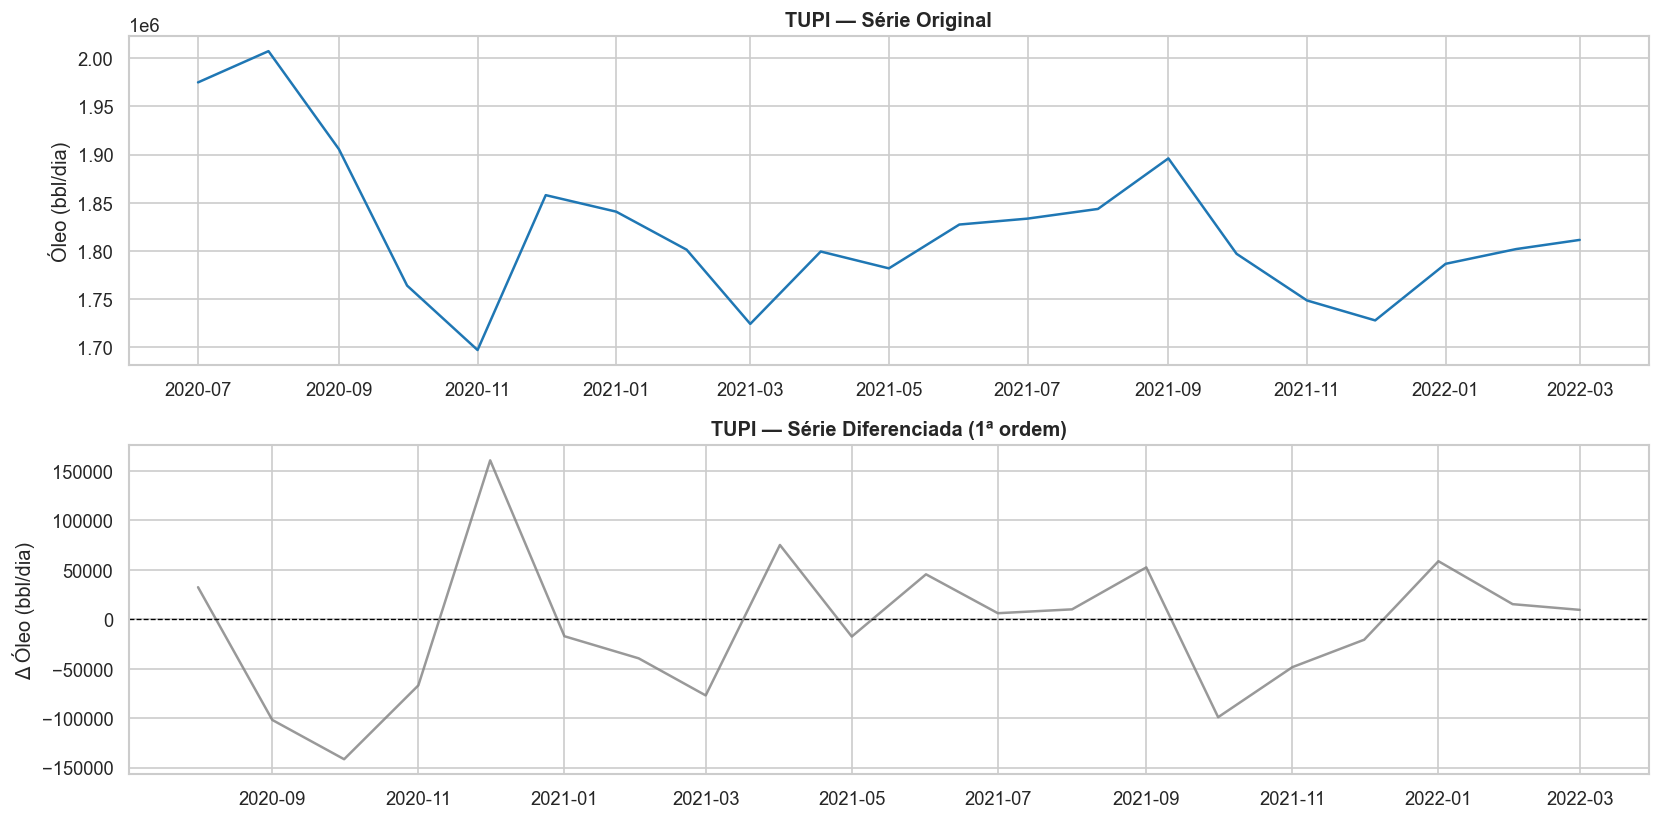

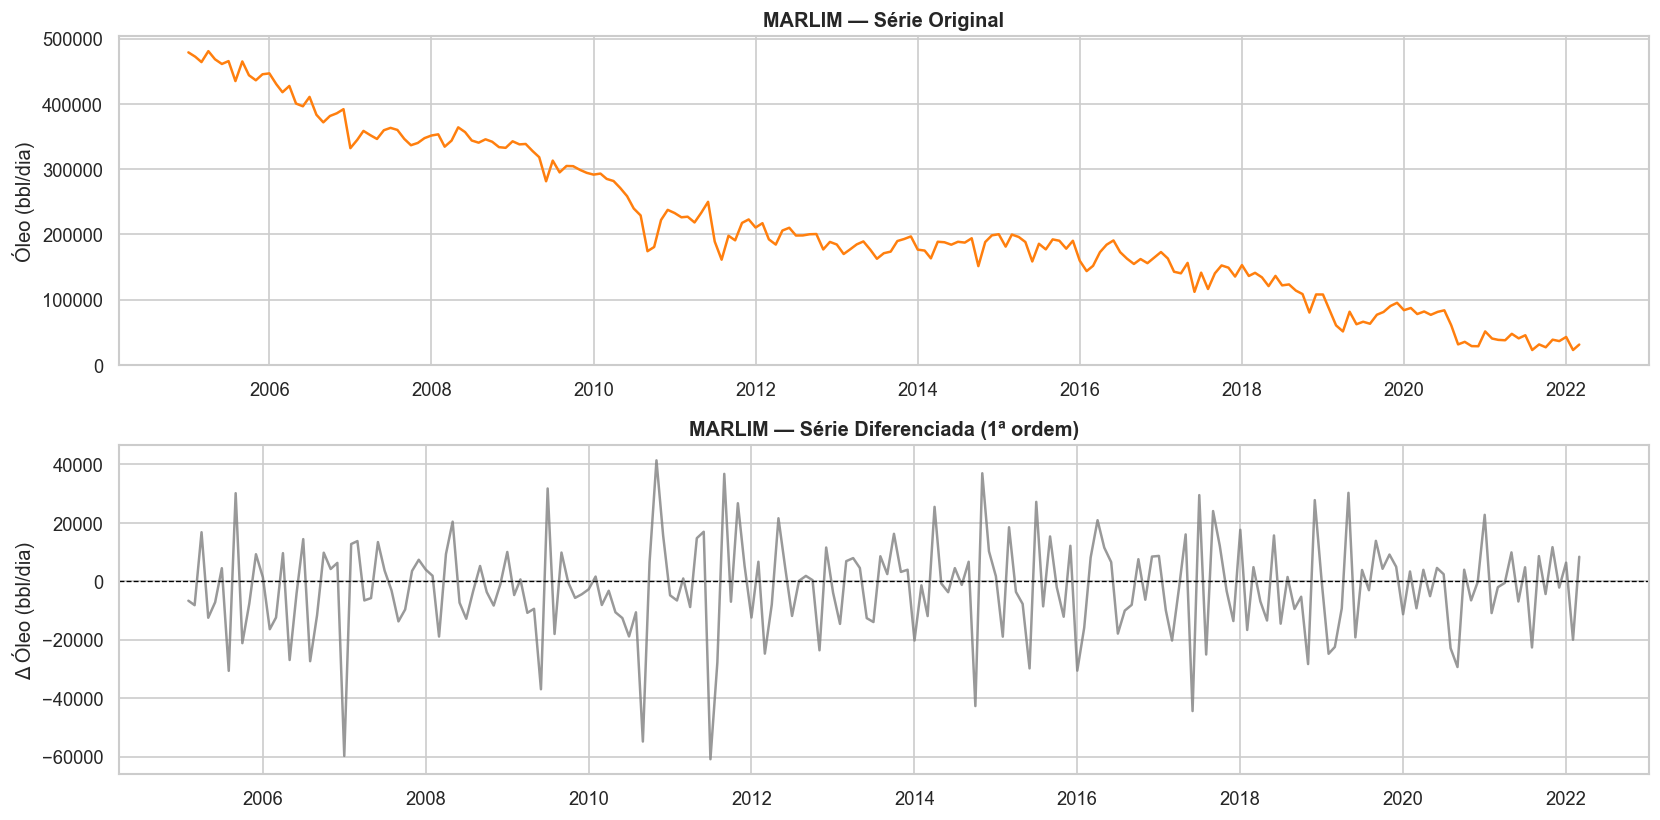

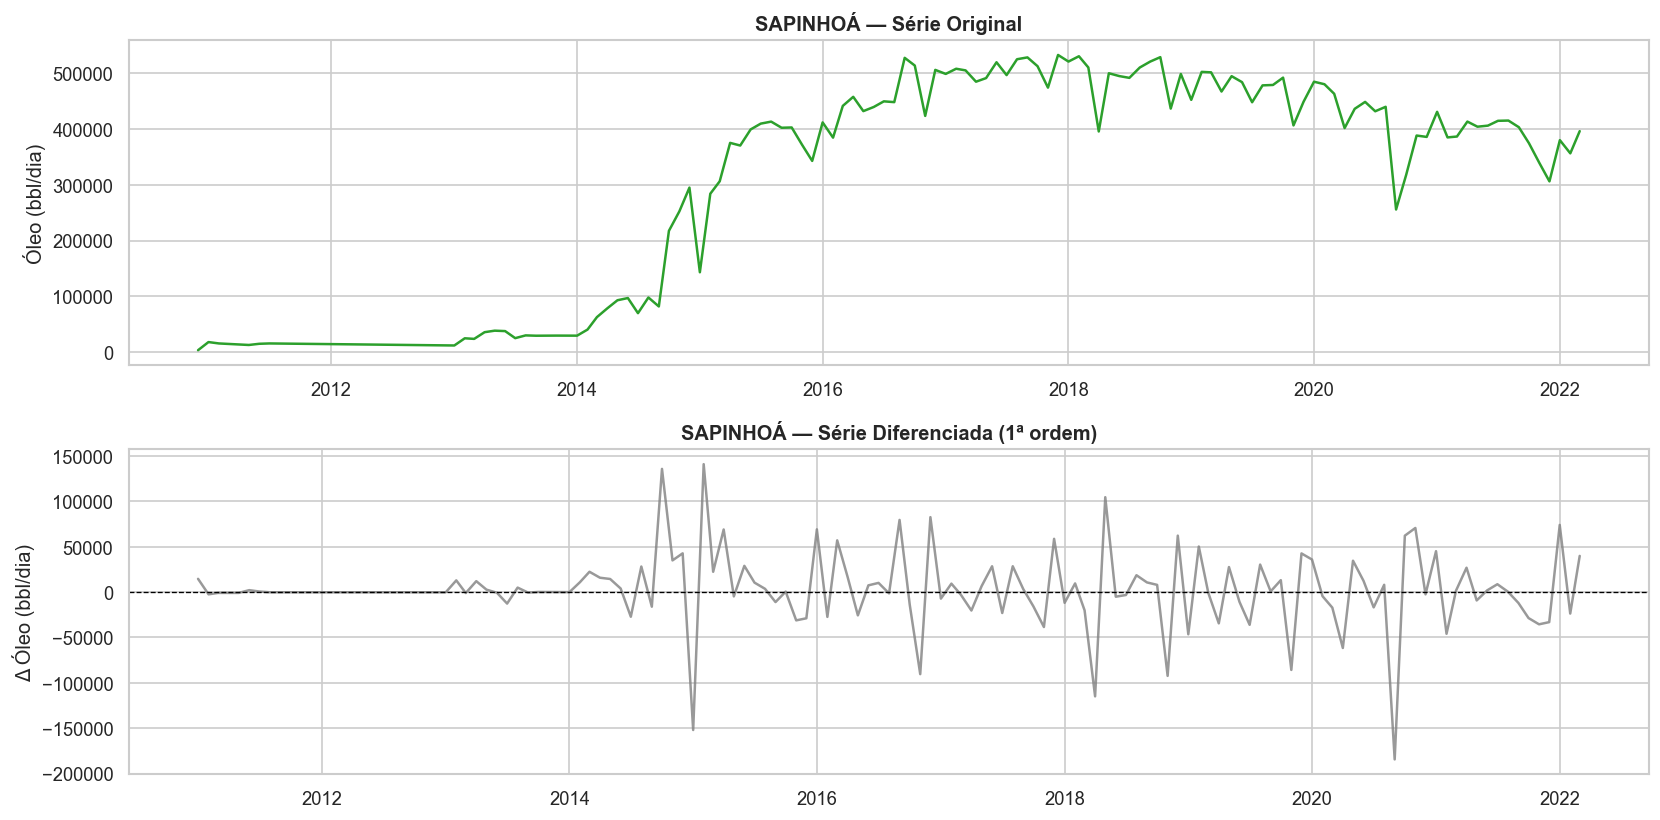

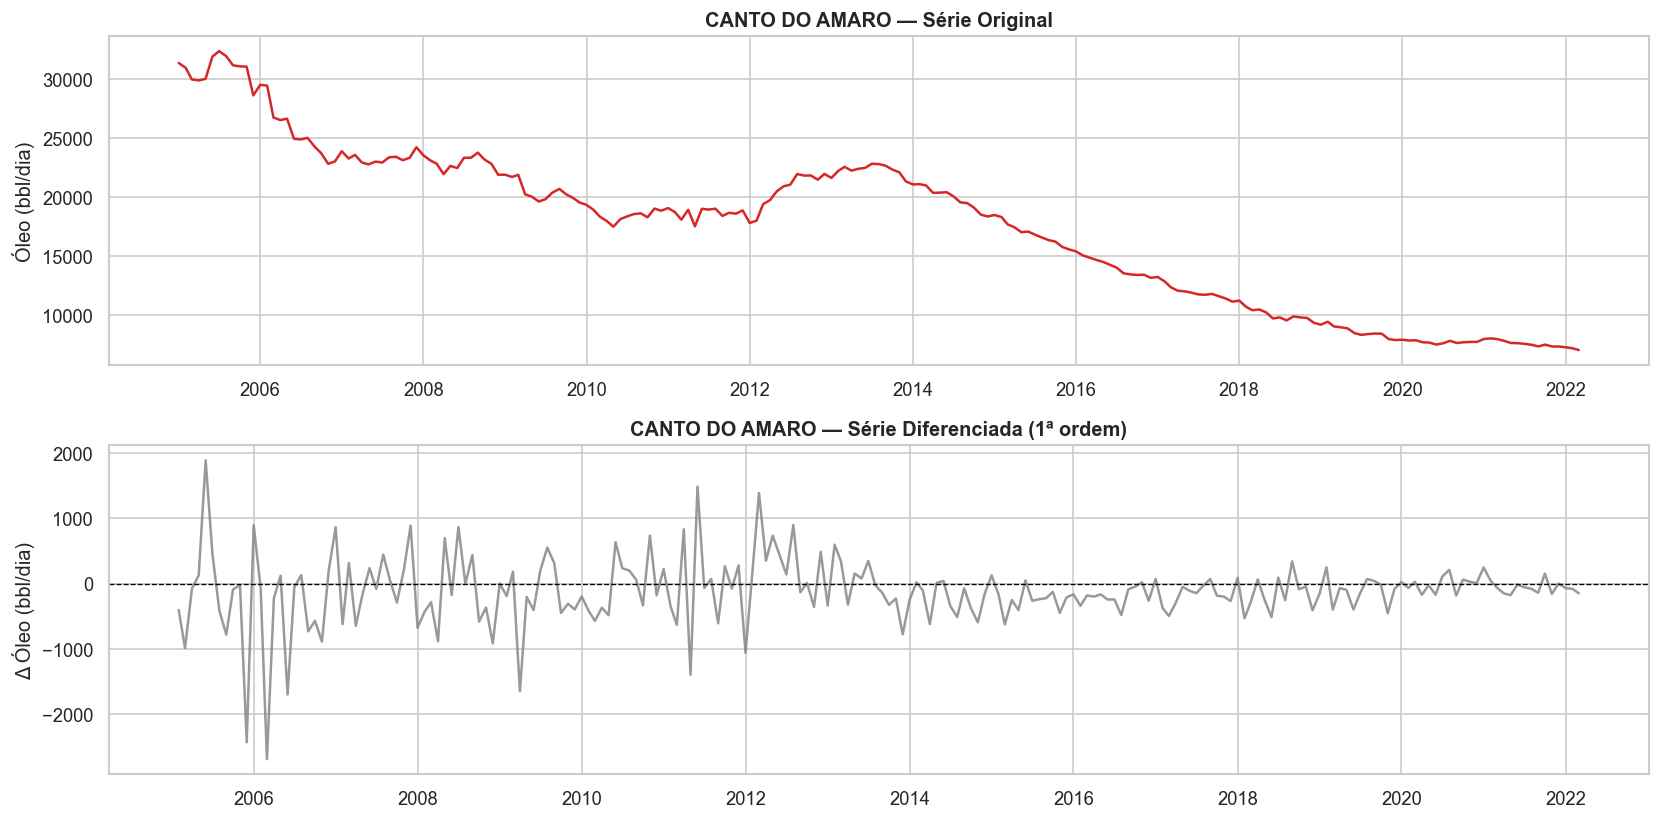

In [18]:
# Visualização: série original vs. diferenciada
for campo in CAMPOS_ALVO:
    dados = (
        df_mensal[df_mensal['Campo'] == campo]
        .set_index('Período')['Óleo (bbl/dia)']
        .sort_index()
    )
    dados = dados[dados > 0].asfreq('MS').interpolate(method='linear')

    if len(dados) < 15:
        continue

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

    ax1.plot(dados.index, dados.values, color=CORES[campo])
    ax1.set_title(f'{campo} — Série Original', fontweight='bold')
    ax1.set_ylabel('Óleo (bbl/dia)')

    ax2.plot(dados.diff().index, dados.diff().values, color='gray', alpha=0.8)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_title(f'{campo} — Série Diferenciada (1ª ordem)', fontweight='bold')
    ax2.set_ylabel('Δ Óleo (bbl/dia)')

    plt.tight_layout()
    plt.show()

## 7. Pipeline do Projeto

O diagrama abaixo descreve as etapas do processo de ciência de dados aplicado a este projeto.

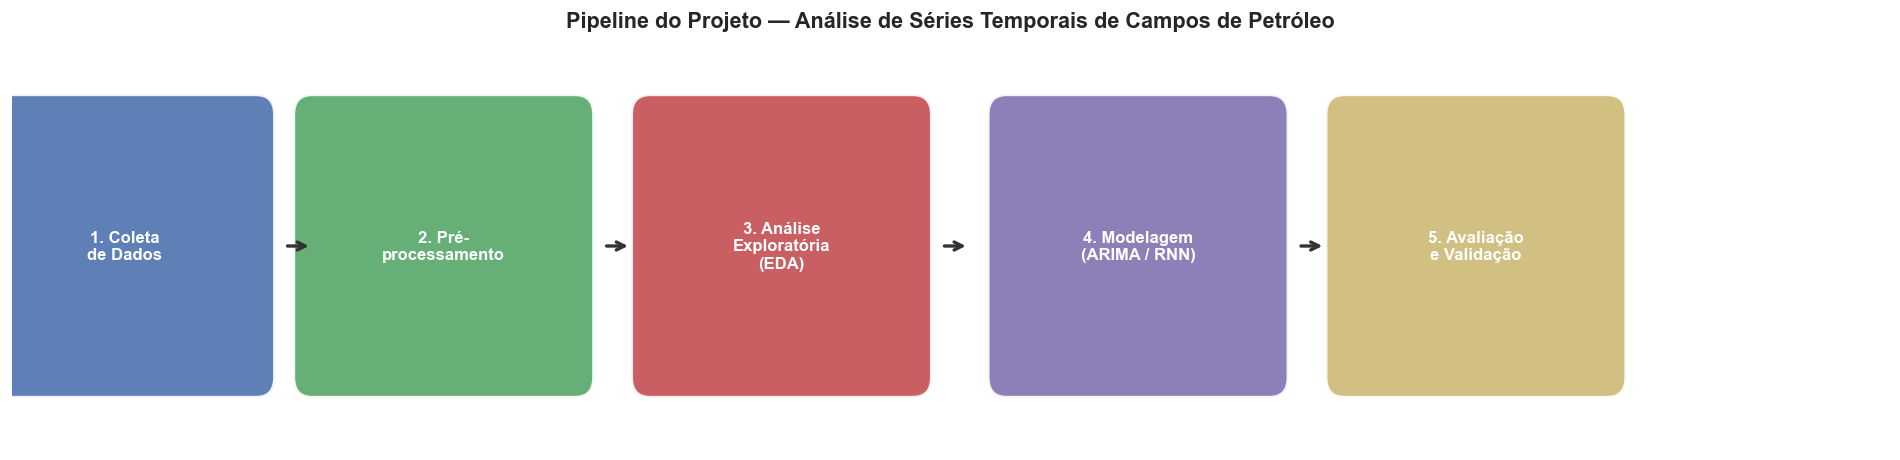

In [19]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis('off')

etapas = [
    ('1. Coleta\nde Dados', 0.5, '#4C72B0'),
    ('2. Pré-\nprocessamento', 2.2, '#55A868'),
    ('3. Análise\nExploratória\n(EDA)', 4.0, '#C44E52'),
    ('4. Modelagem\n(ARIMA / RNN)', 5.9, '#8172B2'),
    ('5. Avaliação\ne Validação', 7.7, '#CCB974'),
]

for label, x, cor in etapas:
    box = mpatches.FancyBboxPatch(
        (x - 0.6, 0.35), 1.4, 1.3,
        boxstyle='round,pad=0.1',
        facecolor=cor, edgecolor='white', linewidth=2, alpha=0.9
    )
    ax.add_patch(box)
    ax.text(x + 0.1, 1.0, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

# Setas
xs = [1.5, 3.2, 5.0, 6.9]
for x in xs:
    ax.annotate('', xy=(x + 0.1, 1.0), xytext=(x - 0.05, 1.0),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=2))

ax.set_title('Pipeline do Projeto — Análise de Séries Temporais de Campos de Petróleo',
             fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

### Descrição do Pipeline

| Etapa | Descrição | Ferramentas |
|---|---|---|
| **1. Coleta de Dados** | Dados públicos da ANP (Agência Nacional do Petróleo) sobre produção mensal por poço, disponibilizados via Kaggle | CSV bruto, ANP Open Data |
| **2. Pré-processamento** | Conversão de tipos, tratamento de nulos, filtragem dos campos de interesse, agregação mensal por campo | `pandas` |
| **3. EDA** | Análise estatística descritiva, visualizações (linha, box plot, heat map), decomposição, ACF/PACF, teste de estacionariedade | `matplotlib`, `seaborn`, `statsmodels` |
| **4. Modelagem** | Implementação de ARIMA/SARIMA e RNN/LSTM para previsão da produção futura | `statsmodels`, `tensorflow`/`keras` |
| **5. Avaliação** | Comparação dos modelos usando MAE, MSE e RMSE; análise dos resíduos | `sklearn.metrics` |

## 8. Levantamento de Técnicas de Modelagem

Com base nos resultados da EDA, duas abordagens serão investigadas na Etapa 3.

In [20]:
# Tabela comparativa das técnicas
tecnicas = {
    'Técnica': ['ARIMA / SARIMA', 'RNN / LSTM'],
    'Tipo': ['Estatístico', 'Deep Learning'],
    'Premissas': [
        'Série estacionária (ou diferenciável); relações lineares',
        'Grande volume de dados; relações não-lineares complexas'
    ],
    'Parâmetros Principais': [
        'p (AR), d (integração), q (MA); P, D, Q, s (sazonal)',
        'Tamanho da janela temporal, unidades LSTM, camadas, dropout'
    ],
    'Vantagens': [
        'Interpretável, bem fundamentado teoricamente, funciona bem com poucas observações',
        'Captura padrões não-lineares e dependências de longo prazo'
    ],
    'Limitações': [
        'Assume linearidade; requer série estacionária',
        'Caixa-preta; exige maior volume de dados e poder computacional'
    ],
    'Métricas de Avaliação': [
        'MAE, MSE, RMSE, AIC, BIC',
        'MAE, MSE, RMSE'
    ]
}

df_tecnicas = pd.DataFrame(tecnicas)
print('Comparativo de Técnicas de Modelagem:')
print(df_tecnicas.to_string(index=False))

Comparativo de Técnicas de Modelagem:
       Técnica          Tipo                                                Premissas                                       Parâmetros Principais                                                                         Vantagens                                                     Limitações    Métricas de Avaliação
ARIMA / SARIMA   Estatístico Série estacionária (ou diferenciável); relações lineares        p (AR), d (integração), q (MA); P, D, Q, s (sazonal) Interpretável, bem fundamentado teoricamente, funciona bem com poucas observações                  Assume linearidade; requer série estacionária MAE, MSE, RMSE, AIC, BIC
    RNN / LSTM Deep Learning  Grande volume de dados; relações não-lineares complexas Tamanho da janela temporal, unidades LSTM, camadas, dropout                        Captura padrões não-lineares e dependências de longo prazo Caixa-preta; exige maior volume de dados e poder computacional           MAE, MSE, RMSE


### Justificativa da Escolha

Com base na EDA realizada:

- **ARIMA/SARIMA** será o modelo baseline, pois é adequado para séries com tendência e componente sazonal identificados, além de ser interpretável e amplamente validado na literatura (BOX; JENKINS, 2015; HYNDMAN; ATHANASOPOULOS, 2021).
- **LSTM (Long Short-Term Memory)** será testado como modelo alternativo, sendo uma arquitetura de rede neural recorrente especialmente projetada para capturar dependências de longo prazo em sequências temporais.
- **Foco no campo Marlim** para o desenvolvimento inicial dos modelos — é o campo com maior histórico de dados e maior produção média, reduzindo riscos de ajuste insuficiente. Os demais campos serão analisados se houver tempo.
- As métricas de comparação serão **MAE**, **MSE** e **RMSE**, avaliadas sobre um conjunto de teste correspondente aos últimos 12 meses da série.

---

## 9. Síntese dos Resultados da EDA

| Campo | Tendência | Sazonalidade | Estacionária? | Observação |
|---|---|---|---|---|
| TUPI | *a preencher após execução* | *a preencher* | *a preencher* | — |
| MARLIM | *a preencher* | *a preencher* | *a preencher* | — |
| SAPINHOÁ | *a preencher* | *a preencher* | *a preencher* | — |
| CANTO DO AMARO | *a preencher* | *a preencher* | *a preencher* | — |

> **Nota:** Preencher a tabela acima com as conclusões visuais dos gráficos de decomposição e o resultado do teste ADF.

---
## Referências

BOX, George E. P.; JENKINS, Gwilym M.; REINSEL, Gregory C.; LJUNG, Greta M. **Time series analysis: forecasting and control.** 5. ed. Hoboken: John Wiley & Sons, 2015.

HYNDMAN, Rob J.; ATHANASOPOULOS, George. **Forecasting: principles and practice.** 3. ed. Melbourne: OTexts, 2021.

MORETTIN, Pedro A.; TOLOI, Clélia M. C. **Análise de séries temporais.** 2. ed. São Paulo: Blucher, 2006.

AGÊNCIA NACIONAL DO PETRÓLEO, GÁS NATURAL E BIOCOMBUSTÍVEIS (ANP). **Dados públicos de produção de petróleo e gás natural.** Rio de Janeiro: ANP, 2024.